In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# Create Sales Dataset
np.random.seed(42)
n = 200

TV = np.random.uniform(0, 300, n)
Radio = np.random.uniform(0, 50, n)
Newspaper = np.random.uniform(0, 100, n)

# Sales depends on advertising spend
Sales = (0.05 * TV + 0.1 * Radio +
         0.01 * Newspaper +
         np.random.normal(5, 2, n))

df = pd.DataFrame({
    'TV': TV.round(1),
    'Radio': Radio.round(1),
    'Newspaper': Newspaper.round(1),
    'Sales': Sales.round(2)
})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSales Range:")
print(f"Min: {df['Sales'].min():.2f}")
print(f"Max: {df['Sales'].max():.2f}")

Dataset Shape: (200, 4)

First 5 rows:
      TV  Radio  Newspaper  Sales
0  112.4   32.1       10.3  12.87
1  285.2    4.2       90.3  19.00
2  219.6    8.1       50.5  17.08
3  179.6   44.9       82.6  17.23
4   46.8   30.3       32.0   9.59

Sales Range:
Min: 2.46
Max: 24.92


In [3]:
# Prepare data
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train 2 models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=" * 45)
print("     SALES PREDICTION RESULTS")
print("=" * 45)
print(f"Linear Regression R2  : {lr_r2*100:.2f}%")
print(f"Random Forest R2      : {rf_r2*100:.2f}%")
print("=" * 45)

if rf_r2 > lr_r2:
    print("🏆 Best Model: Random Forest")
else:
    print("🏆 Best Model: Linear Regression")

     SALES PREDICTION RESULTS
Linear Regression R2  : 89.06%
Random Forest R2      : 84.03%
🏆 Best Model: Linear Regression


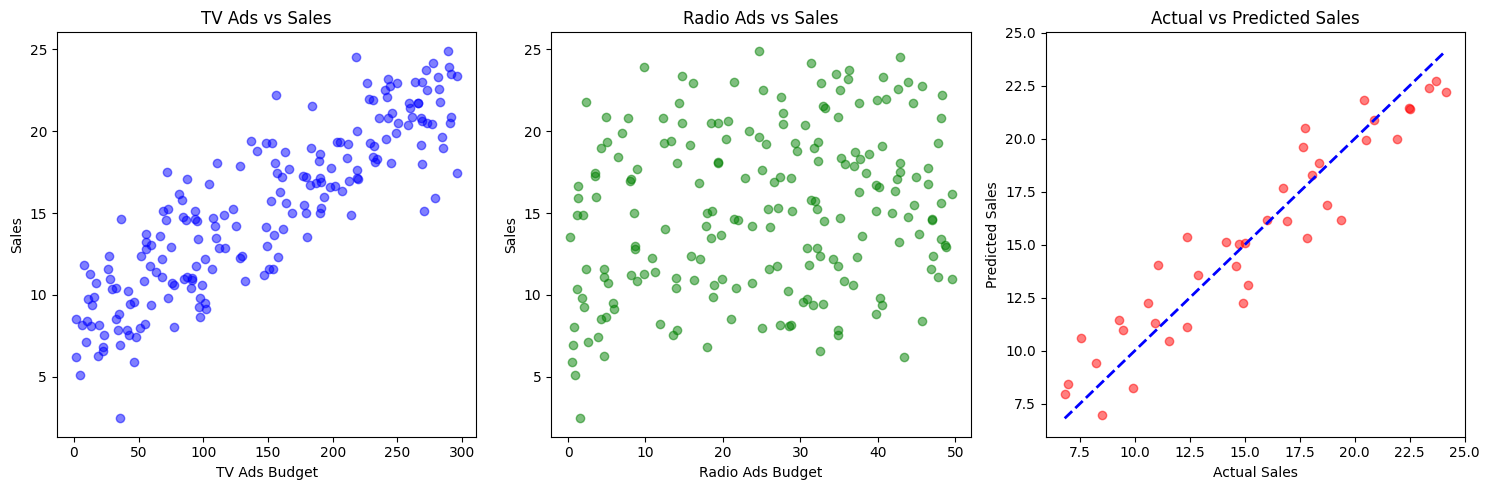

✅ Task 4 Complete!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 - TV vs Sales
axes[0].scatter(df['TV'], df['Sales'],
                color='blue', alpha=0.5)
axes[0].set_xlabel('TV Ads Budget')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Ads vs Sales')

# Chart 2 - Radio vs Sales
axes[1].scatter(df['Radio'], df['Sales'],
                color='green', alpha=0.5)
axes[1].set_xlabel('Radio Ads Budget')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio Ads vs Sales')

# Chart 3 - Actual vs Predicted
axes[2].scatter(y_test, lr_pred,
                color='red', alpha=0.5)
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'b--', lw=2)
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].set_title('Actual vs Predicted Sales')

plt.tight_layout()
plt.show()
print("✅ Task 4 Complete!")